## _Spoticore Stage 2 PyTorchified_

We are going to refactor the stage 2 code to (kinda) match PyTorch's public API for building neural networks similar to spoticore.


### Imports

In [2]:
from typing import Final
import torch
import torch.nn.functional as F
import torch.nn.init as Init
from math import sqrt
from collections.abc import Iterator
from typing import Protocol
from reader import read_all_unique_words


%matplotlib inline
import matplotlib.pyplot as plt

### Constants

In [3]:
SEED: Final[int] = 534150593
N_EMBD: Final[int] = 10
N_HIDDEN: Final[int] = 100

BLOCK_SIZE: Final[int] = 3

### Random seed generator

In [4]:
g = torch.Generator().manual_seed(SEED)

### Neural network architecture

In [5]:
class Layer(Protocol):
    def __call__(self, x: torch.Tensor) -> torch.Tensor: ...
    def parameters(self) -> Iterator[torch.Tensor]: ...

In [6]:
class Linear:
    def __init__(self, fan_in: int, fan_out: int, bias: bool = True) -> None:
        # Kaiming Init with a gain of 1 for linear layer.
        self.weight = torch.randn((fan_in, fan_out), generator=g) / sqrt(fan_in)
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self) -> Iterator[torch.Tensor]:
        yield self.weight
        if self.bias is not None:
            yield self.bias

In [7]:
class BatchNorm1d:
    def __init__(
        self, num_features: int, eps: float = 1e-5, momentum: float = 0.1
    ) -> None:
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # bn gain
        self.gamma = torch.ones(num_features)
        # bn bias
        self.beta = torch.zeros(num_features)
        # bn running mean and variance
        self.running_mean = torch.zeros(num_features)
        self.running_var = torch.ones(num_features)

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        # forward pass: calculate activations
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var

        # normalize to unit variance
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)

        self.out = self.gamma * xhat + self.beta

        # update running mean and var
        if self.training:
            with torch.no_grad():
                self.running_mean = (
                    1 - self.momentum
                ) * self.running_mean + self.momentum * xmean
                self.running_var = (
                    1 - self.momentum
                ) * self.running_var + self.momentum * xvar

        return self.out

    def parameters(self) -> Iterator[torch.Tensor]:
        yield self.gamma
        yield self.beta

In [8]:
class Tanh:
    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        self.out = torch.tanh(x)
        return self.out

    def parameters(self) -> Iterator[torch.Tensor]:
        return iter(())

### Build character-index mappings from training data

In [9]:
type StoiMap = dict[str, int]
type ItosMap = dict[int, str]


def build_vocab_mappings() -> tuple[list[str], StoiMap, ItosMap]:
    words = read_all_unique_words()

    chars = sorted(set("".join(words)))

    # create mappings with special token "." at index 0.
    stoi = {char: i + 1 for i, char in enumerate(chars)}
    stoi["."] = 0

    itos = {i: char for char, i in stoi.items()}

    return words, stoi, itos

### Construct model inputs from training data

In [10]:
words, stoi, itos = build_vocab_mappings()
vocab_size = len(stoi)

In [11]:
def construct_model_inputs(
    words: list[str], stoi: StoiMap, block_size: int = 3
) -> tuple[torch.Tensor, torch.Tensor]:
    block_size = 3

    X, Y = [], []

    for word in words:
        prev_chars_is = [0] * block_size
        for char in word + ".":
            nxt_char_i = stoi[char]
            X.append(prev_chars_is)
            Y.append(nxt_char_i)
            prev_chars_is = prev_chars_is[1:] + [nxt_char_i]

    return torch.tensor(X), torch.tensor(Y)

### Construct embedding lookup matrix

In [12]:
# Char -> N_EMBD row vector
C = torch.randn((vocab_size, N_EMBD), generator=g)

### Create deep MLP

In [13]:
layers = [
    Linear(N_EMBD * BLOCK_SIZE, N_HIDDEN),
    Tanh(),
    Linear(N_HIDDEN, N_HIDDEN),
    Tanh(),
    Linear(N_HIDDEN, N_HIDDEN),
    Tanh(),
    Linear(N_HIDDEN, N_HIDDEN),
    Tanh(),
    Linear(N_HIDDEN, N_HIDDEN),
    Tanh(),
    Linear(N_HIDDEN, vocab_size),
]

### Kaiming Init for tanh

In [14]:
gain = Init.calculate_gain("tanh")

# make last layer less confident
with torch.no_grad():
    layers[-1].weight *= 0.1
    # apply gain for all tanh pre-activations
    # output layer does not perform tanh
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= gain

### Initialize model parameters for training

In [15]:
params = [C] + [p for layer in layers for p in layer.parameters()]
print("Total parameters: ", sum(p.nelement() for p in params))

# ensure all parameters take part in backprogation
for p in params:
    p.requires_grad = True

Total parameters:  47607


### Train the model

In [16]:
X, Y = construct_model_inputs(words, stoi)

In [ ]:
iterations = 20_000
batch_size = 32
lrs = (0.2, 0.01)

# Loss in iterations passsed through log10()
losses = []


# Track update ratio to parameters per training iteration.
udrs = []

for i in range(iterations):
    # Construct mini batch of inputs
    chosen_idxs = torch.randint(0, X.shape[0], (batch_size,), generator=g)

    # Extract the batches.
    X_batch, Y_batch = X[chosen_idxs], Y[chosen_idxs]

    # Forward pass.
    emb = C[X_batch]

    x = emb.view((batch_size, N_EMBD * BLOCK_SIZE))

    for layer in layers:
        x = layer(x)

    loss = F.cross_entropy(x, Y_batch)

    # Backward pass.
    for layer in layers:
        layer.out.retain_grad()

    for p in params:
        p.grad = None

    loss.backward()

    # Update params
    lr = lrs[0] if i < 10_000 else lrs[1]

    for p in params:
        if p.grad is not None:
            p.data += -lr * p.grad

    # track stats
    if i % 10_000 == 0:
        print(f"{i:7d} / {iterations}: {loss.item():.4f}")

    losses.append(loss.log10().item())

    with torch.no_grad():
        if p.grad is not None:
            udrs.append(
                (lr * param.grad.std() / param.data.std()).log10().item()
                for param in params
            )

    #! remove
    break

      0 / 20000: 3.5617


### Parameter update ratios `udrs`

We use std to measure the ratio to get a stable and easy to understand measure of update magnitude relative to parameter scale. 

We dont use mean to calculate the ratio because mean can be near zero and make computed ratios undefined or misleading.

- If the ratio is too small (e.g., < 0.001): Updates are tiny relative to parameters so learning may be slow.

- If the ratio is too large (e.g., > 0.1): Updates are large relative to parameters so learning may be unstable or diverge.

Ideal stable update range is often around 0.001–0.01.


In [31]:
udrs

[<generator object <genexpr> at 0x7fe7e99659a0>]

## Visualizations

### Visualize tanh activation density in forward pass

Change the gain for the tanh layers and observe the activation distribution.

layer 1 (Tanh): mean -0.01, std 0.74, saturated: 18.16%
layer 3 (Tanh): mean -0.01, std 0.69, saturated: 9.06%
layer 5 (Tanh): mean -0.01, std 0.66, saturated: 6.44%
layer 7 (Tanh): mean -0.01, std 0.66, saturated: 5.62%
layer 9 (Tanh): mean +0.01, std 0.66, saturated: 5.75%


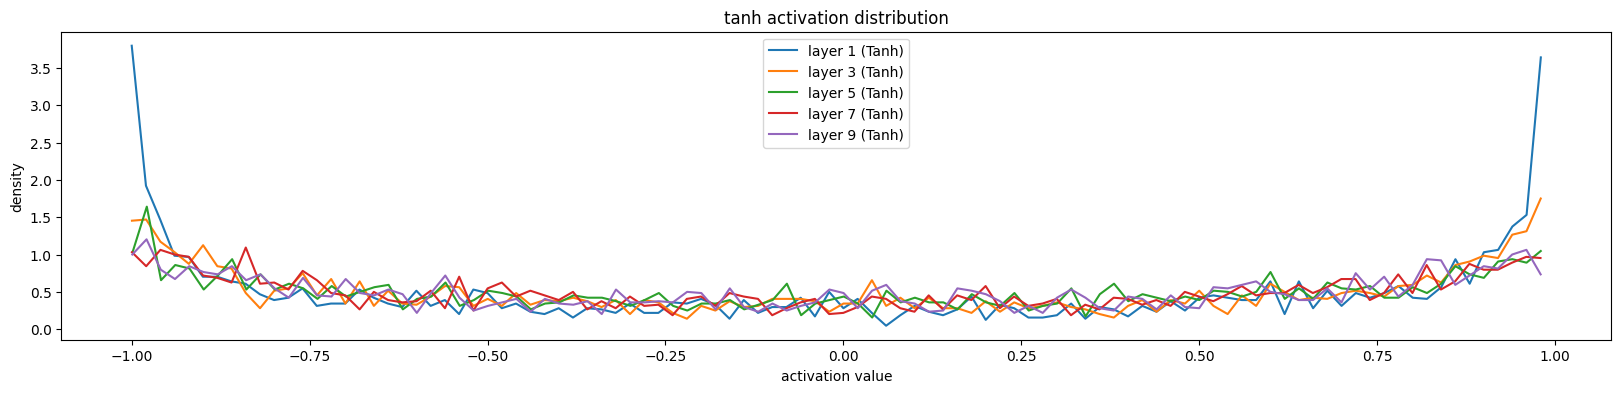

In [28]:
# Histogram visualization.

plt.figure(figsize=(20, 4))

legends: list[str] = []

for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        # Retrieve tanh layer's activations.
        acts = layer.out.detach()

        print(
            "layer %d (%s): mean %+.2f, std %.2f, saturated: %.2f%%"
            % (
                i,
                layer.__class__.__name__,
                acts.mean(),
                acts.std(),
                (acts.abs() > 0.97).float().mean() * 100,
            )
        )
        # Construct layer's x, y values.
        hx, hy = torch.histogram(acts, density=True)

        # Plot layer's activation distribution.
        plt.plot(hy[:-1].detach(), hx.detach())

        legends.append(f"layer {i} ({layer.__class__.__name__})")


plt.legend(legends)
plt.title("tanh activation distribution")
plt.xlabel("activation value")
plt.ylabel("density");

### Visualize tanh gradient density in forward pass

Change the gain for the tanh layers and observe the activation gradient distribution.

layer 1 (Tanh): mean +0.000019, std 7.809413e-04
layer 3 (Tanh): mean -0.000022, std 7.205998e-04
layer 5 (Tanh): mean +0.000003, std 6.186223e-04
layer 7 (Tanh): mean +0.000021, std 5.257545e-04
layer 9 (Tanh): mean +0.000014, std 4.380719e-04


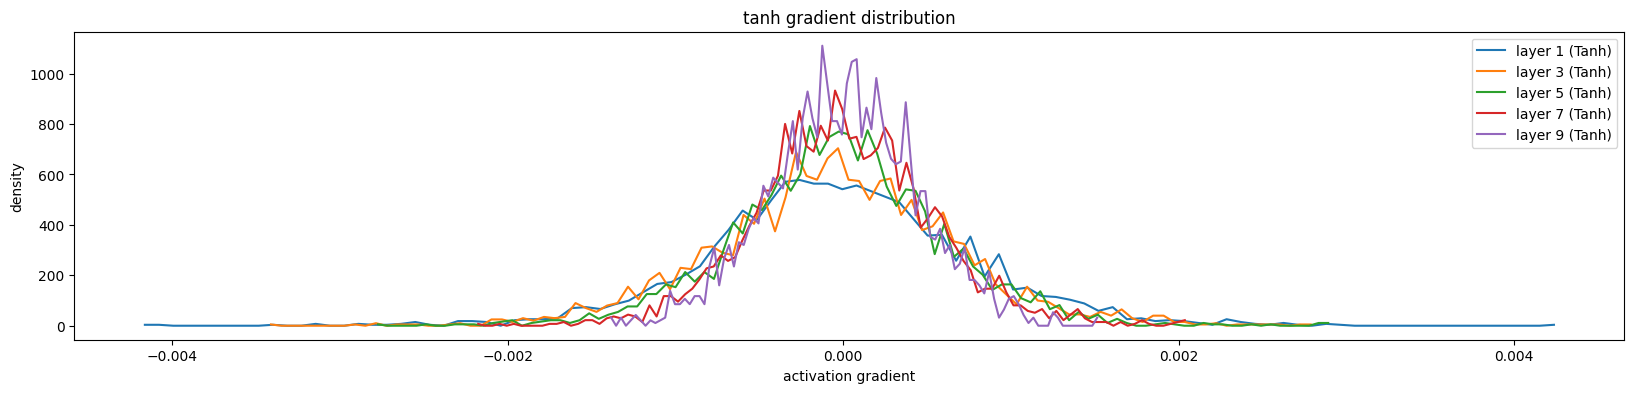

In [29]:
plt.figure(figsize=(20, 4))

legends: list[str] = []

for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        # Retrieve tanh layer's gradients.
        grads = layer.out.grad

        assert grads is not None

        print(
            "layer %d (%s): mean %+f, std %e"
            % (
                i,
                layer.__class__.__name__,
                grads.mean(),
                grads.std(),
            )
        )
        # Construct layer's x, y values.
        hx, hy = torch.histogram(grads, density=True)

        # Plot layer's activation gradient distribution.
        plt.plot(hy[:-1].detach(), hx.detach())

        legends.append(f"layer {i} ({layer.__class__.__name__})")


plt.legend(legends)
plt.title("tanh gradient distribution")
plt.xlabel("activation gradient")
plt.ylabel("density");

### Gradient distribution of 2d parameters

weight   (37, 10) | mean +0.000055  | std 1.958212e-03 | grad:data ratio 1.968162e-03
weight  (30, 100) | mean +0.000110  | std 2.623535e-03 | grad:data ratio 8.579082e-03
weight (100, 100) | mean -0.000020  | std 1.981750e-03 | grad:data ratio 1.181294e-02
weight (100, 100) | mean +0.000033  | std 1.673762e-03 | grad:data ratio 1.007330e-02
weight (100, 100) | mean -0.000006  | std 1.375234e-03 | grad:data ratio 8.274640e-03
weight (100, 100) | mean +0.000004  | std 1.193816e-03 | grad:data ratio 7.241778e-03
weight  (100, 37) | mean -0.000000  | std 2.088258e-02 | grad:data ratio 1.582411e+00


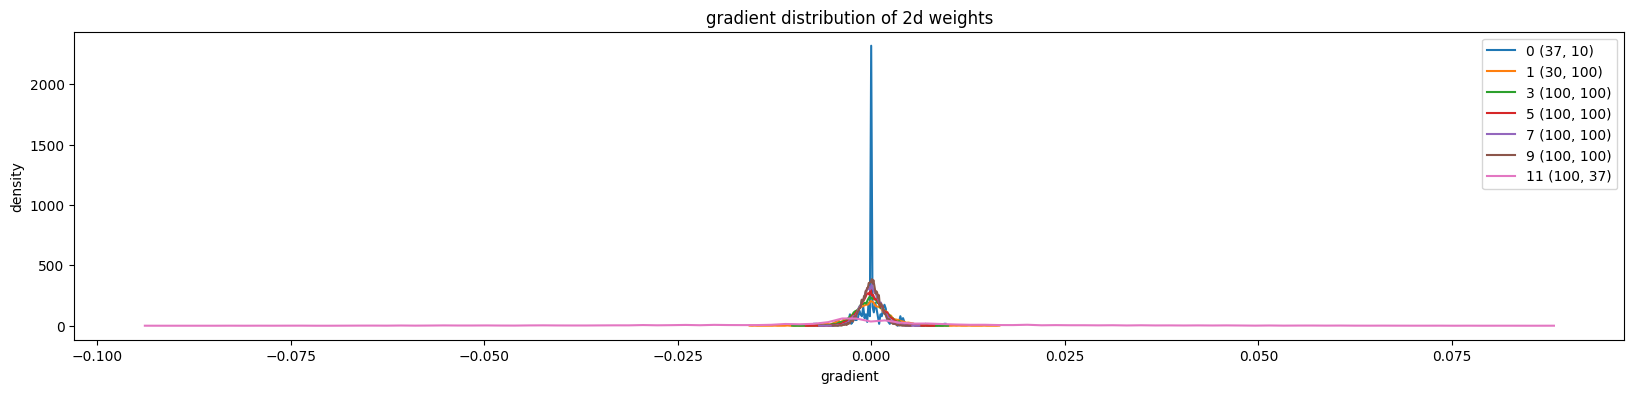

In [30]:
# Visualize the histogram.

plt.figure(figsize=(20, 4))
legends = []

for i, p in enumerate(params):
    if p.ndim == 2 and p.grad is not None:
        print(
            "weight %10s | mean %+f  | std %e | grad:data ratio %e"
            % (
                tuple(p.shape),
                p.grad.mean().item(),
                p.grad.std().item(),
                (p.grad.std() / p.data.std()).item(),
            )
        )
        # Derive histogram x, y values
        hx, hy = torch.histogram(p.grad, density=True)
        # Plot the graph
        plt.plot(hy[:-1].detach(), hx.detach())
        legends.append(f"{i} {tuple(p.shape)}")


plt.legend(legends)
plt.title("gradient distribution of 2d weights")
plt.xlabel("gradient")
plt.ylabel("density");